# Exercícios de regressão linear

## Altura explica o peso?

Considere os dados abaixo:

In [1]:
peso = [45,50,60,55,58,56,48,53]
altura = [1.54,1.56,1.65,1.60,1.65,1.63,1.58,1.59]

### Tarefa:

Exploração preliminar

1. Crie um dataframe com os dados
1. Determine qual é a variável independente (preditora) e a dependente (alvo)
1. Desenhe um gráfico de dispersão mostrando a relação entre elas
1. Determine se a relação é ou não é linear

Criação do modelo

1. Ajuste um modelo linear ao dados
1. Extraia os coeficientes angular e linear do modelo

Fazer predições

1. Desenhe a reta de regressão (gráfico de linha) sobre os dados originais (gráfico de dispersão)
1. Faça a predição do peso de alguém que tem 1.68

1. Crie um dataframe com os dados

In [2]:
import pandas as pd

df = pd.DataFrame({
    "altura": altura,
    "peso": peso
    })

df

,altura,peso
0,1.54,45
1,1.56,50
2,1.65,60
3,1.60,55
4,1.65,58
5,1.63,56
6,1.58,48
7,1.59,53


2. Determine qual é a variável independente (preditora) e a dependente (alvo)

Perguta é: Altura explica peso? Então:

- Preditora é $Altura$
- Alvo é $Peso$


3. Desenhe um gráfico de dispersão mostrando a relação entre elas

<Axes: xlabel='altura', ylabel='peso'>

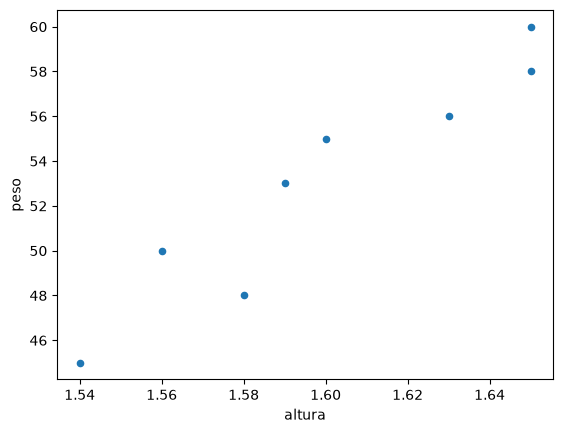

In [3]:
df.plot(kind="scatter",
        x="altura",
        y="peso")

4. Determine se a relação é ou não é linear

Olhando o gráfico de dispersão notamos que quando a altura cresce o peso mais ou menos acompanha. Há uma certa relação linear entre as variáveis. 

Então: sim.

Criação do modelo

5. Ajuste um modelo linear ao dados

In [4]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
X = df[["altura"]] # altura é a variável preditora
y = df["peso"] # peso é a variável alvo

modelo.fit(X, y) # <= AQUI estamos ajustando o modelo aos dados
                 # isso significa: encontrar a reta que passa mais
                 # próxima aos dados


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[119.83]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['altura']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-138.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


6. Extraia os coeficientes angular e linear do modelo

In [5]:
a = modelo.coef_ # coeficiente angular
b = modelo.intercept_ # coeficiente linear

print(f"Coef. angular: {a}")
print(f"Coef. linear: {b}")

Coef. angular: [119.82758621]
Coef. linear: -138.59913793103485


Fazer predições

7. Desenhe a reta de regressão (gráfico de linha) sobre os dados originais (gráfico de dispersão)

Agora vamos traçar uma **reta** usando os valores das alturas que já temos porém os valores dos pesos (alvos) serão dados pela equação da reta que usa os coeficientes ajustados pelo modelo. Ou seja, *não são os pesos que observamos*!

In [7]:
# calculando os pontos da reta de regressão
import numpy as np

x = np.array(df["altura"])
y_pred = a * x + b # y predito pelo modelo para cada valor de x

print("Todos os valores de y preditos pelo modelo:")
print(y_pred)

Todos os valores de y preditos pelo modelo:
[45.93534483 48.33189655 59.11637931 53.125      59.11637931 56.71982759
 50.72844828 51.92672414]


Plotando os pontos observados (gráfico de dispersão)

Plotando os pontos da reta de regressão

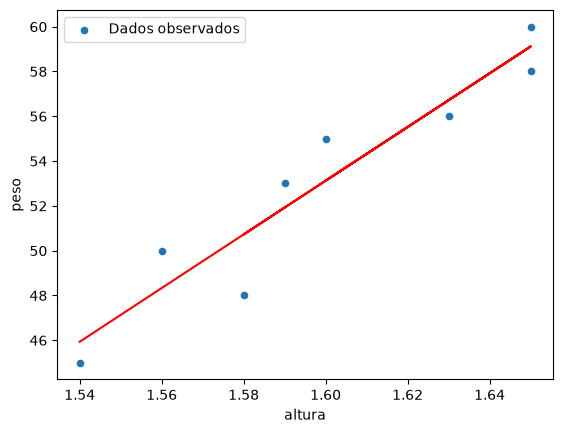

In [12]:
# plot da reta de regressão - x=dados observados, y = y_pred (dados preditos pelo modelo)
import matplotlib.pyplot as plt
# plot dos dados observados

df.plot(kind="scatter",
        x="altura",
        y="peso",
        label="Dados observados")

plt.plot(    
    x,
    y_pred,
    color="red"
)

8. Faça a predição do peso de alguém que tem 1.68

In [13]:
# Prevendo o peso de alguém que tem 1.68 altura
altura_nao_observada = 1.68
peso_predito = modelo.predict(pd.DataFrame({
    "altura": [altura_nao_observada] 
}))
                                                              
peso_predito

array([62.7112069])